
LAB 3 - ORIGINAL DATA
  age sex cp trestbps chol fbs restecg thalach exang oldpeak slope ca thal
1  63   1  1      145  233   1       2     150     0     2.3     3  0    6
2  67   1  4      160  286   0       2     108     1     1.5     2  3    3
3  67   1  4      120  229   0       2     129     1     2.6     2  2    7
4  37   1  3      130  250   0       0     187     0     3.5     3  0    3
5  41   0  2      130  204   0       2     172     0     1.4     1  0    3
6  56   1  2      120  236   0       0     178     0     0.8     1  0    3
  target
1      0
2      2
3      1
4      0
5      0
6      0

Invalid BP values introduced.

LAB 3 - CLEANED BP SAMPLE
   trestbps BP_clean
1       145      145
2       160      160
3       120      120
4       130      130
5       130      130
6       120      120
7       140      140
8       120      120
9       130      130
10      140      140
11      140      140
12      140      140
13      130      130
14       NA       NA
15      172     

Ratio error: Invalid denominator: BP is zero, NA, or invalid.

Ratio error: Invalid denominator: BP is zero, NA, or invalid.



[1] 1.666667       NA       NA

Loop Time:
   user  system elapsed 
  0.009   0.000   0.010 

Vectorized Time:
   user  system elapsed 
      0       0       0 

Loop vs Vectorized Performance:
      Method Time_seconds
1   For Loop         0.01
2 Vectorized         0.00

LAB 3 - VALIDATION
Missing BP: 9 
Minimum BP: 94 
Maximum BP: 250 
Mean BP: 133.8844 
Median BP: 130 
Negative values remaining: 0 
Values >250 remaining: 0 

cleaned_heart_data.csv created.

LAB 4 - ORIGINAL ADULT DATA
  age        workclass fnlwgt education education_num     marital_status
1  39        State-gov  77516 Bachelors            13      Never-married
2  50 Self-emp-not-inc  83311 Bachelors            13 Married-civ-spouse
3  38          Private 215646   HS-grad             9           Divorced
4  53          Private 234721      11th             7 Married-civ-spouse
5  28          Private 338409 Bachelors            13 Married-civ-spouse
6  37          Private 284582   Masters            14 Married-civ-spo

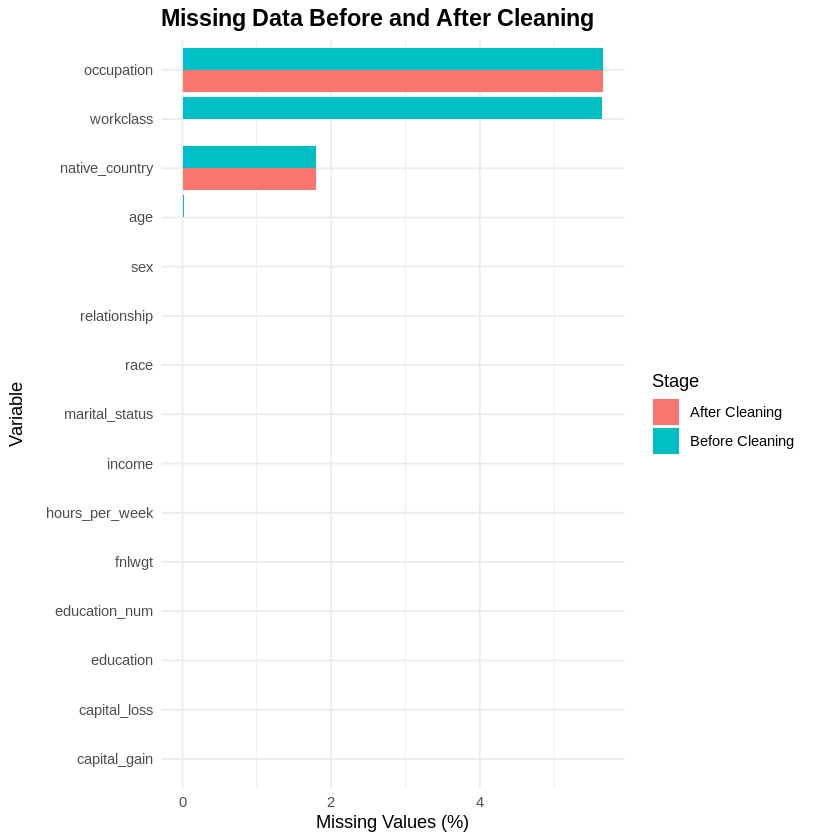


SKIMR SUMMARY:
── Data Summary ────────────────────────
                           Values
Name                       adult 
Number of rows             32561 
Number of columns          15    
_______________________          
Column type frequency:           
  character                9     
  numeric                  6     
________________________         
Group variables            None  

── Variable type: character ────────────────────────────────────────────────────
  skim_variable  n_missing complete_rate min max empty n_unique whitespace
1 workclass              0         1       7  16     0        9          0
2 education              0         1       3  12     0       16          0
3 marital_status         0         1       7  21     0        7          0
4 occupation          1843         0.943   5  17     0       14          0
5 relationship           0         1       4  14     0        6          0
6 race                   0         1       5  18     0        5        

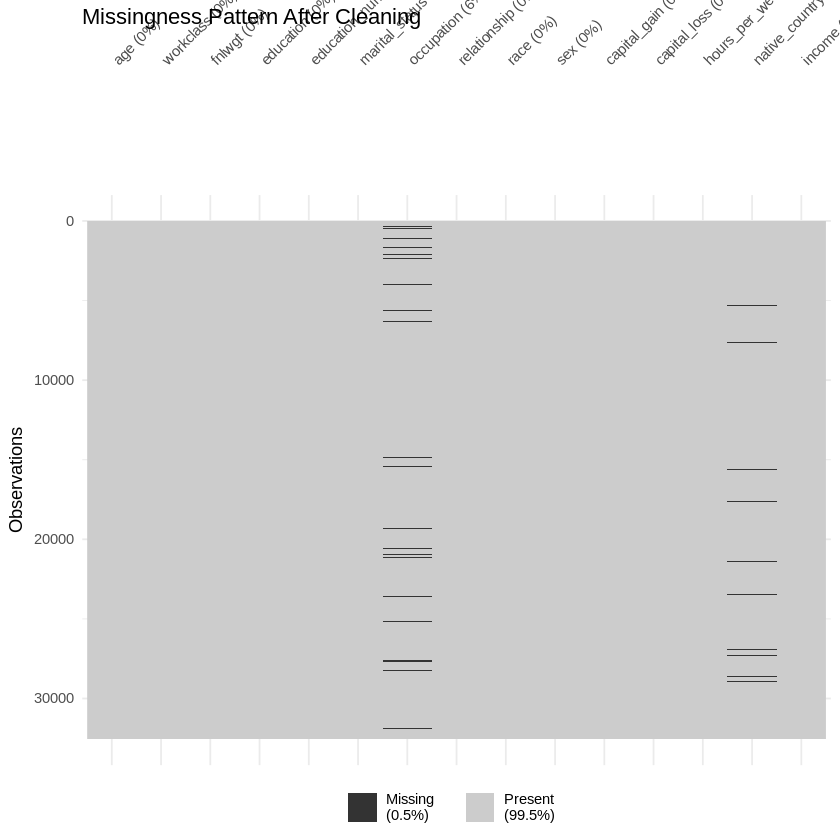

In [3]:
# ---------- INSTALL & LOAD PACKAGES ----------
install.packages(c("readr", "dplyr", "naniar", "skimr"), quiet = TRUE)

library(readr)
library(dplyr)
library(naniar)
library(skimr)


# ================================================================
# LAB 3 - CONTROL FLOW FOR DATA CLEANING
# ================================================================

# ---------- 1. LOAD UCI HEART DISEASE DATA ----------
heart_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

heart <- read.csv(
  heart_url,
  header = FALSE,
  na.strings = "?"
)

colnames(heart) <- c(
  "age", "sex", "cp", "trestbps", "chol",
  "fbs", "restecg", "thalach", "exang",
  "oldpeak", "slope", "ca", "thal", "target"
)

cat("\nLAB 3 - ORIGINAL DATA\n")
print(head(heart))


# ---------- 2. INTRODUCE DATA-ENTRY PROBLEMS ----------
set.seed(123)

heart$trestbps[sample(1:nrow(heart), 5)] <- -20
heart$trestbps[sample(1:nrow(heart), 5)] <- NA
heart$trestbps[sample(1:nrow(heart), 5)] <- 320

cat("\nInvalid BP values introduced.\n")


# ---------- 3. CUSTOM BP CLEANING FUNCTION ----------
clean_bp <- function(x) {
  if (is.na(x)) {
    return(NA)
  } else if (x < 0) {
    return(NA)
  } else if (x > 250) {
    return(250)
  } else {
    return(x)
  }
}

heart$BP_clean <- sapply(heart$trestbps, clean_bp)

cat("\nLAB 3 - CLEANED BP SAMPLE\n")
print(head(heart[, c("trestbps", "BP_clean")], 15))


# ---------- 4. TRY-CATCH ERROR HANDLING ----------
safe_mean <- function(x) {
  tryCatch(
    mean(x, na.rm = TRUE),
    warning = function(w) {
      message("Warning while calculating mean: ", w$message)
      NA
    },
    error = function(e) {
      message("Error while calculating mean: ", e$message)
      NA
    }
  )
}

safe_ratio <- function(chol, bp) {
  tryCatch(
    if (is.na(bp) || bp == 0 || !is.finite(bp))
      stop("Invalid denominator: BP is zero, NA, or invalid.")
    else chol / bp,
    error = function(e) {
      message("Ratio error: ", e$message)
      NA
    }
  )
}

cat("\nSafe Mean BP:", safe_mean(heart$BP_clean), "\n")

cat("\nSafe Cholesterol/BP Examples:\n")
print(
  c(
    safe_ratio(200, 120),
    safe_ratio(200, 0),
    safe_ratio(200, NA)
  )
)


# ---------- 5. LOOP-BASED CLEANING ----------
bp_loop <- heart$trestbps

loop_time <- system.time({
  for (i in seq_along(bp_loop)) {
    if (!is.na(bp_loop[i]) && bp_loop[i] < 0)
      bp_loop[i] <- NA
    else if (!is.na(bp_loop[i]) && bp_loop[i] > 250)
      bp_loop[i] <- 250
  }
})


# ---------- 6. VECTORIZED CLEANING ----------
bp_vector <- heart$trestbps

vector_time <- system.time({
  bp_vector[bp_vector < 0] <- NA
  bp_vector[bp_vector > 250] <- 250
})


cat("\nLoop Time:\n")
print(loop_time)

cat("\nVectorized Time:\n")
print(vector_time)


# ---------- 7. LOOP VS VECTORIZED COMPARISON ----------
comparison <- data.frame(
  Method = c("For Loop", "Vectorized"),
  Time_seconds = c(
    loop_time["elapsed"],
    vector_time["elapsed"]
  )
)

cat("\nLoop vs Vectorized Performance:\n")
print(comparison)


# ---------- 8. VALIDATE CLEANED BP ----------
cat("\nLAB 3 - VALIDATION\n")

cat("Missing BP:", sum(is.na(heart$BP_clean)), "\n")
cat("Minimum BP:", min(heart$BP_clean, na.rm = TRUE), "\n")
cat("Maximum BP:", max(heart$BP_clean, na.rm = TRUE), "\n")
cat("Mean BP:", mean(heart$BP_clean, na.rm = TRUE), "\n")
cat("Median BP:", median(heart$BP_clean, na.rm = TRUE), "\n")

cat(
  "Negative values remaining:",
  sum(heart$BP_clean < 0, na.rm = TRUE),
  "\n"
)

cat(
  "Values >250 remaining:",
  sum(heart$BP_clean > 250, na.rm = TRUE),
  "\n"
)


# ---------- 9. SAVE CLEANED HEART DATA ----------
write.csv(
  heart,
  "cleaned_heart_data.csv",
  row.names = FALSE
)

cat("\ncleaned_heart_data.csv created.\n")


# ================================================================
# LAB 4 - ADVANCED MISSING DATA HANDLING
# ================================================================

# ---------- 10. LOAD UCI ADULT DATA ----------
adult_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

adult <- read.csv(
  adult_url,
  header = FALSE,
  strip.white = TRUE,
  na.strings = "?"
)

colnames(adult) <- c(
  "age", "workclass", "fnlwgt", "education",
  "education_num", "marital_status",
  "occupation", "relationship", "race",
  "sex", "capital_gain", "capital_loss",
  "hours_per_week", "native_country", "income"
)

cat("\nLAB 4 - ORIGINAL ADULT DATA\n")
print(head(adult))

# ================================================================
# LAB 4 - ADVANCED MISSING DATA HANDLING
# ================================================================

# ---------- 11. INTRODUCE MISSING / INVALID VALUES ----------
set.seed(123)

adult$age[sample(1:nrow(adult), 5)] <- 999
adult$age[sample(1:nrow(adult), 5)] <- NaN
adult$workclass[sample(1:nrow(adult), 5)] <- ""


# ---------- 12. IDENTIFY NA, NaN, NULL, BLANK ----------
cat("\nMissing NA values:\n")
print(sum(is.na(adult)))

cat("\nNaN values in age:\n")
print(sum(is.nan(adult$age)))

x <- NULL
cat("\nNULL demonstration:\n")
print(is.null(x))

cat("\nBlank workclass values:\n")
print(sum(adult$workclass == "", na.rm = TRUE))

cat("\nImpossible age = 999:\n")
print(sum(adult$age == 999, na.rm = TRUE))


# ================================================================
# 13. MISSING DATA BEFORE CLEANING
# ================================================================

before_summary <- naniar::miss_var_summary(adult)

cat("\nMissing Summary BEFORE Cleaning:\n")
print(before_summary)


# ---------- 14. CUSTOM MEDIAN IMPUTATION FUNCTION ----------
median_impute <- function(x) {
  med <- median(x, na.rm = TRUE)
  x[is.na(x) | is.nan(x)] <- med
  x
}


# ================================================================
# 15. CLEAN INVALID / MISSING VALUES
# ================================================================

# Convert impossible age to NA
adult$age[adult$age == 999] <- NA

# Replace blank/missing workclass
adult$workclass[
  is.na(adult$workclass) | adult$workclass == ""
] <- "Unknown"

# Numeric median imputation
numeric_cols <- c(
  "age",
  "fnlwgt",
  "education_num",
  "capital_gain",
  "capital_loss",
  "hours_per_week"
)

for (v in numeric_cols) {
  adult[[v]] <- median_impute(adult[[v]])
}


# ================================================================
# 16. MISSING DATA AFTER CLEANING
# ================================================================

after_summary <- naniar::miss_var_summary(adult)

cat("\nMissing Summary AFTER Cleaning:\n")
print(after_summary)


# ================================================================
# 17. BEFORE VS AFTER COMPARISON
# ================================================================

missing_compare <- before_summary %>%
  select(variable, n_miss, pct_miss) %>%
  rename(
    Before_Count = n_miss,
    Before_Percent = pct_miss
  ) %>%
  left_join(
    after_summary %>%
      select(variable, n_miss, pct_miss) %>%
      rename(
        After_Count = n_miss,
        After_Percent = pct_miss
      ),
    by = "variable"
  )

cat("\nBEFORE VS AFTER MISSING DATA:\n")
print(missing_compare)


# ================================================================
# 18. TOTAL MISSING VALUES
# ================================================================

total_before <- sum(
  missing_compare$Before_Count
)

total_after <- sum(
  missing_compare$After_Count
)

cat(
  "\nTotal Missing Values Before Cleaning:",
  total_before,
  "\n"
)

cat(
  "Total Missing Values After Cleaning:",
  total_after,
  "\n"
)

cat(
  "Missing Values Removed:",
  total_before - total_after,
  "\n"
)


# ================================================================
# 19. IMPROVED BEFORE VS AFTER VISUALIZATION
# ================================================================

plot_data <- rbind(
  data.frame(
    Variable = missing_compare$variable,
    Missing_Percentage = missing_compare$Before_Percent,
    Stage = "Before Cleaning"
  ),
  data.frame(
    Variable = missing_compare$variable,
    Missing_Percentage = missing_compare$After_Percent,
    Stage = "After Cleaning"
  )
)

ggplot2::ggplot(
  plot_data,
  ggplot2::aes(
    x = reorder(Variable, Missing_Percentage),
    y = Missing_Percentage,
    fill = Stage
  )
) +
  ggplot2::geom_col(
    position = "dodge"
  ) +
  ggplot2::coord_flip() +
  ggplot2::labs(
    title = "Missing Data Before and After Cleaning",
    x = "Variable",
    y = "Missing Values (%)",
    fill = "Stage"
  ) +
  ggplot2::theme_minimal() +
  ggplot2::theme(
    plot.title = ggplot2::element_text(
      face = "bold",
      size = 14
    )
  )


# ================================================================
# 20. MISSINGNESS PATTERN VISUALIZATION
# ================================================================

naniar::vis_miss(adult) +
  ggplot2::ggtitle(
    "Missingness Pattern After Cleaning"
  )


# ================================================================
# 21. SKIMR VALIDATION
# ================================================================

cat("\nSKIMR SUMMARY:\n")
print(skimr::skim(adult))


# ================================================================
# 22. FINAL VALIDATION
# ================================================================

cat("\nLAB 4 - FINAL VALIDATION\n")

cat(
  "Age values equal to 999:",
  sum(adult$age == 999, na.rm = TRUE),
  "\n"
)

cat(
  "Blank workclass values:",
  sum(adult$workclass == "", na.rm = TRUE),
  "\n"
)

cat(
  "Missing age values:",
  sum(is.na(adult$age)),
  "\n"
)

cat(
  "Complete rows:",
  sum(complete.cases(adult)),
  "\n"
)


# ================================================================
# 23. SAVE CLEANED DATA
# ================================================================

write.csv(
  adult,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

cat(
  "\ncleaned_adult_data.csv created successfully.\n"
)